In [1]:
import pandas as pd
import json

df = pd.read_csv("../data/processed/listing_sample.csv")

with open("../data/processed/taxonomy.json") as f:
    taxonomy = json.load(f)

print(df.shape)
df.head()

(1000, 7)


,L_ListingID,L_Address,L_City,beds,baths,price,remarks
0,1173229459,1153 S South 2nd Street,Alhambra,3.0,2.0,1200000,Prime location! This property sits moments fro...
1,1176115570,7686 Papyrus Place 3,Rancho Cucamonga,2.0,2.0,635000,Welcome to this beautifully maintained 2-bedro...
2,1189264520,741 W Hill,Long Beach,3.0,2.0,899000,"Welcome to 741 W Hill St, a renovated 3-bedroo..."
3,1174585916,172 Bahia,Covina,4.0,4.0,729000,"Recently remodeled a modern, well-maintained h..."
4,1181593591,2511 Mistletoe Dr,Hayward,6.0,2.0,1049950,The home features 6 bedrooms 2 bath all on a s...


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   L_ListingID  1000 non-null   int64  
 1   L_Address    998 non-null    object 
 2   L_City       999 non-null    object 
 3   beds         998 non-null    float64
 4   baths        1000 non-null   float64
 5   price        1000 non-null   int64  
 6   remarks      1000 non-null   object 
dtypes: float64(2), int64(2), object(3)
memory usage: 54.8+ KB


In [3]:
df["remark_length"] = df["remarks"].str.len()

df["remark_length"].describe()

count    1000.000000
mean     1319.301000
std       589.210143
min        51.000000
25%       906.750000
50%      1268.000000
75%      1661.750000
max      3788.000000
Name: remark_length, dtype: float64

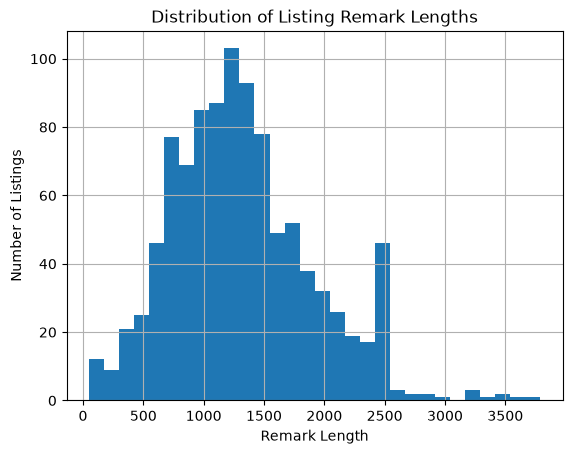

In [8]:
import matplotlib.pyplot as plt

df["remark_length"].hist(bins=30)
plt.xlabel("Remark Length")
plt.ylabel("Number of Listings")
plt.title("Distribution of Listing Remark Lengths")
plt.show()

In [9]:
from collections import Counter
import nltk

all_text = " ".join(
    df["remarks"]
    .dropna()
    .astype(str)
    .str.lower()
)

tokens = [
    token
    for token in nltk.word_tokenize(all_text)
    if token.isalpha()
]

unigram_counts = Counter(tokens)

unigram_counts.most_common(20)

[('and', 9265),
 ('the', 8612),
 ('a', 7830),
 ('with', 3590),
 ('to', 3419),
 ('of', 2973),
 ('for', 2450),
 ('home', 2350),
 ('this', 2176),
 ('in', 2097),
 ('living', 1816),
 ('is', 1722),
 ('an', 1693),
 ('room', 1267),
 ('or', 1167),
 ('offers', 1106),
 ('space', 1079),
 ('kitchen', 921),
 ('private', 840),
 ('features', 807)]

In [10]:
from nltk.util import ngrams

bigram_counts = Counter(ngrams(tokens, 2))

bigram_counts.most_common(20)

[(('and', 'a'), 1061),
 (('in', 'the'), 686),
 (('of', 'the'), 641),
 (('with', 'a'), 629),
 (('to', 'the'), 624),
 (('the', 'home'), 620),
 (('this', 'home'), 432),
 (('access', 'to'), 383),
 (('is', 'a'), 361),
 (('a', 'private'), 357),
 (('primary', 'suite'), 322),
 (('one', 'of'), 318),
 (('welcome', 'to'), 316),
 (('floor', 'plan'), 309),
 (('living', 'room'), 309),
 (('and', 'the'), 309),
 (('and', 'an'), 295),
 (('from', 'the'), 288),
 (('natural', 'light'), 285),
 (('features', 'a'), 281)]

In [11]:
taxonomy_df = pd.DataFrame(taxonomy["terms"])

taxonomy_df["category"].value_counts()

category
interior_feature    56
exterior_feature    30
amenity             25
location            25
property_type       20
condition           20
financial           20
view                15
Name: count, dtype: int64

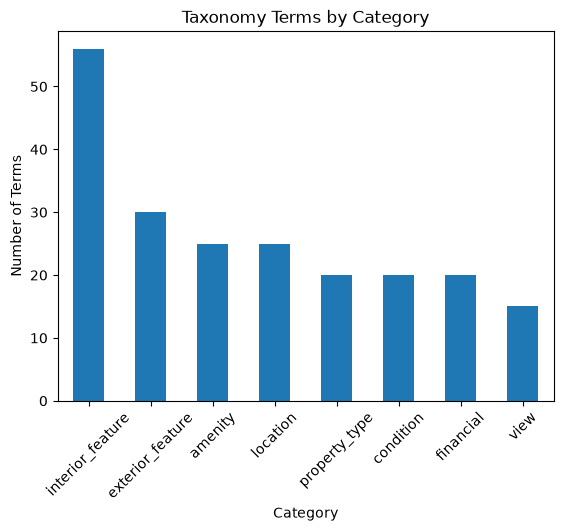

In [12]:
taxonomy_df["category"].value_counts().plot(kind="bar")

plt.xlabel("Category")
plt.ylabel("Number of Terms")
plt.title("Taxonomy Terms by Category")
plt.xticks(rotation=45)
plt.show()

In [13]:
terms = [
    item["term"].lower()
    for item in taxonomy["terms"]
]

def has_taxonomy_term(text):
    text = str(text).lower()
    return any(term in text for term in terms)

coverage = df["remarks"].apply(has_taxonomy_term).mean()

print(f"Taxonomy coverage: {coverage:.2%}")

Taxonomy coverage: 99.40%


## Key Findings

- The dataset contains 1,000 listing remarks.
- Listing remarks average roughly 1,300 characters in length.
- Common real estate concepts include kitchens, living spaces, garages, pools, and primary suites.
- The taxonomy contains more than 200 terms across 8 categories.
- The taxonomy covers more than 99% of sampled listing remarks.